# Deconvolution

In [1]:
# mv this notebook in src folder
# or
# set sys path to src folder
import os, sys
path_to_scr_folder=os.path.join(os.path.dirname(os.path.abspath('')), 'src')
sys.path.append(path_to_scr_folder)


In [185]:
import plot
from read_chroma import read_only_chroma, read_chromato_and_chromato_cube
import matplotlib.pyplot as plt
from identification import compute_matches_identification, cohort_identification_alignment_input_format_txt, cohort_identification_to_csv, sample_identification
from matching import matching_nist_lib_from_chromato_cube
import projection
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import mass_spec
from sklearn.cluster import DBSCAN
from scipy.signal import savgol_filter
from skimage.restoration import estimate_sigma
from dbscan_peak import detection_mass_par_mass_Dog
import dbscan_peak
from whittaker_eilers import WhittakerSmoother


In [ ]:
from whittaker_eilers import WhittakerSmoother
from scipy.interpolate import interp1d
whittaker_smoother = WhittakerSmoother(lmbda=25, order=1, data_length = len(window))
smoothed_data = whittaker_smoother.smooth(window)




In [183]:
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'

chromato, time_rn=read_only_chroma(filename, mod_time=1.7)

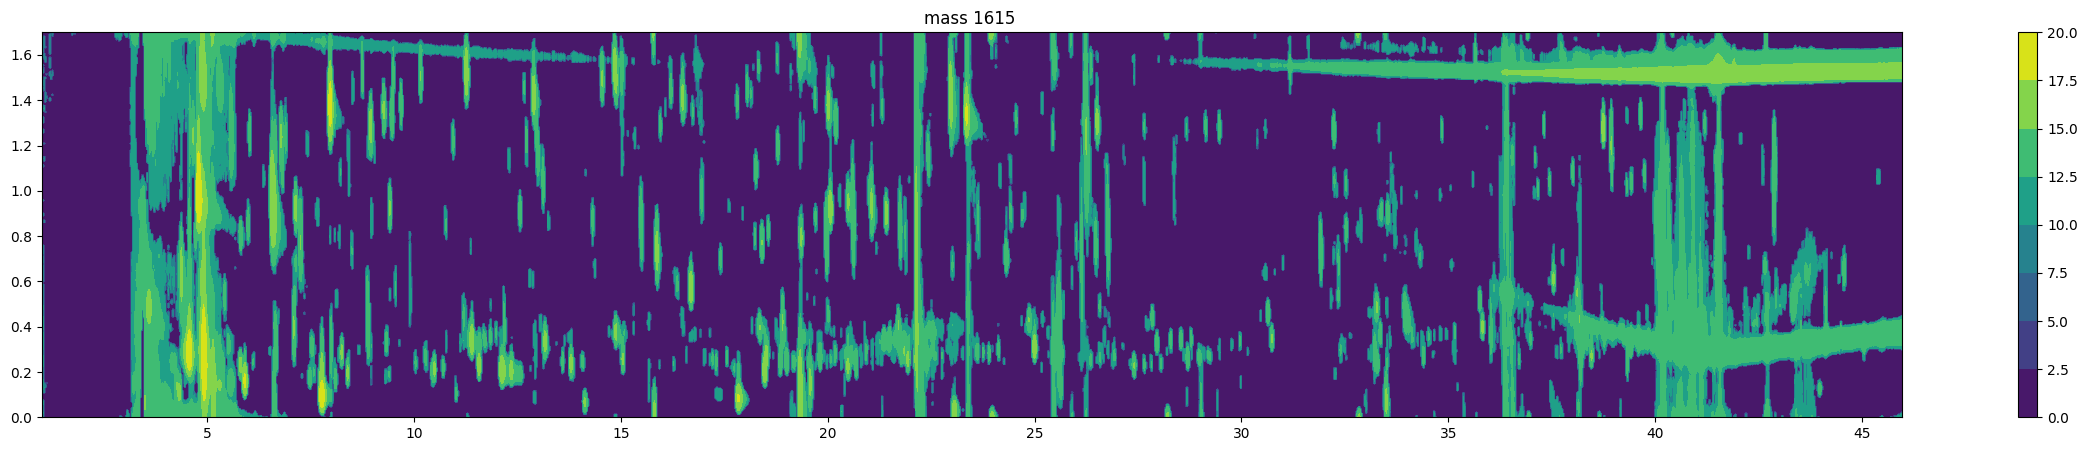

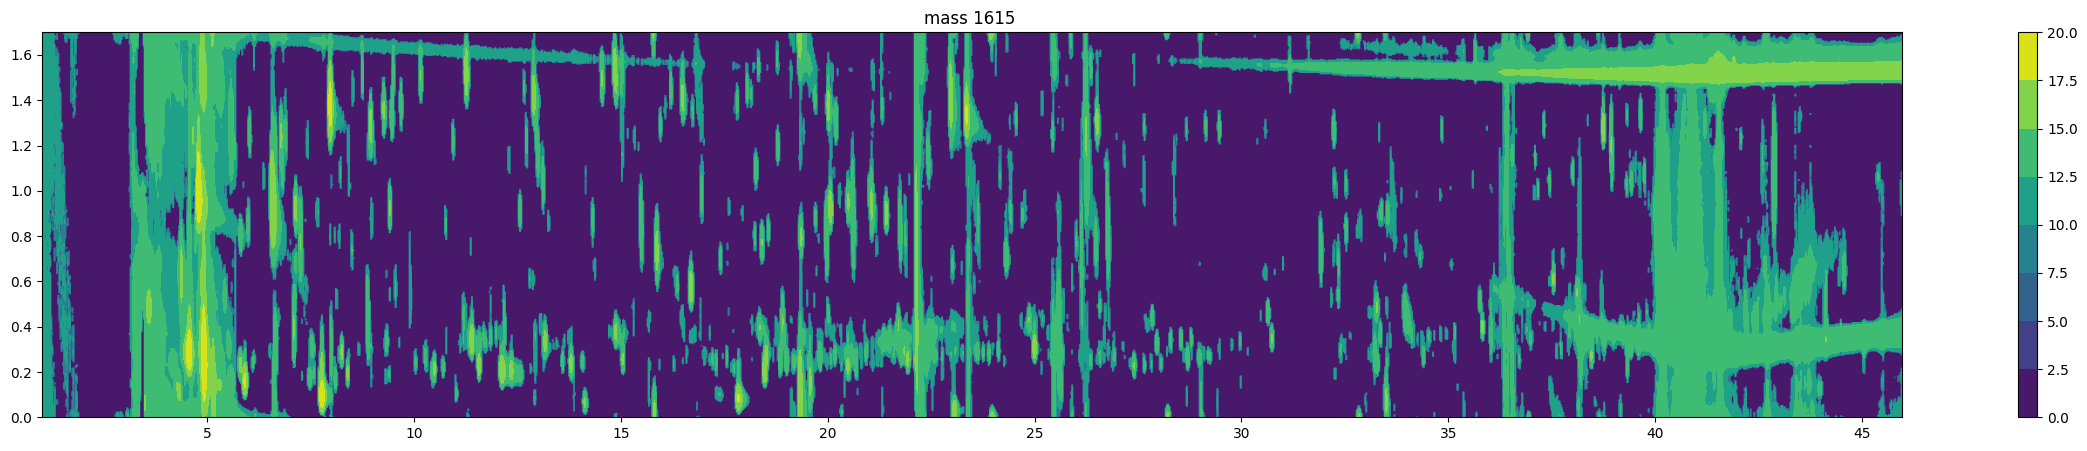

In [323]:
correct=baseline_correct(chromato,block_size=10)
plot.visualizer2(((correct),time_rn), title="mass " + str(i+35) + " " , log_chromato=True,  mod_time=1.7, rt1_window=4, rt2_window=1.1)
correct=baseline_correct(chromato,block_size=15)
plot.visualizer2(((correct),time_rn), title="mass " + str(i+35) + " " , log_chromato=True,  mod_time=1.7, rt1_window=4, rt2_window=1.1)


Loaded 103007595 mass values
Non-finite mass values: 0
[]
[]


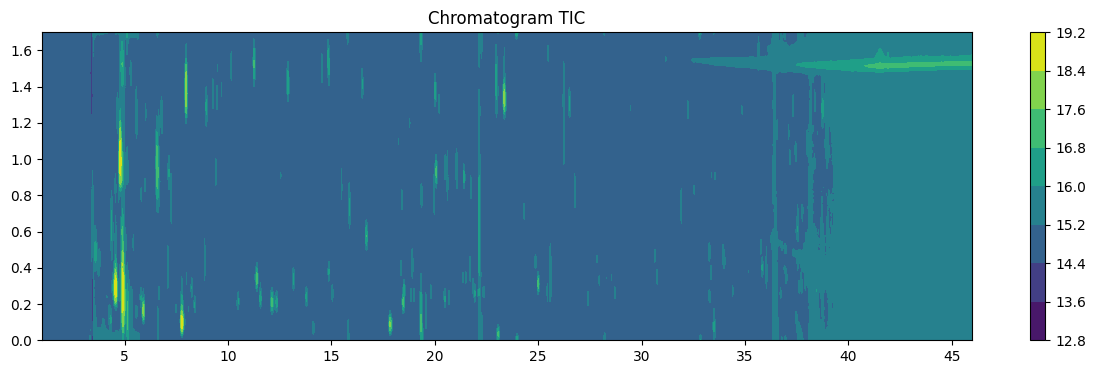

chromato read 19.452105283737183 s
--- 83.08294320106506 seconds --- to compute full spectra centroid
full spectra computed 85.29977989196777 s


In [322]:
filename="/app/GCxGC/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename="D:/VOLATIL-CF_03/751316_QCd20new.cdf"
filename="D:/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
filename='D:/cdf centroid/B-A-009-751353-gauche-ReCIVA.cdf'
#filename='D:/cdf centroid/B-K-031-751355-Tedlar.cdf'
filename="D:/DC volatil cf 8/2025-04-16_751318_QCnew23EI.cdf"
filename = "D:/GCxGC/gamme/751343_gamme_1ppm.cdf"
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'

chromato, time_rn, chromato_cube, sigma, mass_range=read_chromato_and_chromato_cube(filename, mod_time=1.7, pre_process=False)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

# --------- 1. Gaussienne 2D bi-asymétrique (centres fixes, pas d'offset) ---------
def twoD_Gaussian_bi_asym_fixed_center(coords, amplitude, sigma_x1, sigma_x2, sigma_y1, sigma_y2, xo, yo):
    """
    coords: (x, y) meshgrid
    sigma_x1 / sigma_x2 : écart-type à gauche/droite
    sigma_y1 / sigma_y2 : écart-type en bas/haut
    """
    x, y = coords
    dx = x - xo
    dy = y - yo

    sigma_x = np.where(dx < 0, sigma_x1, sigma_x2)
    sigma_y = np.where(dy < 0, sigma_y1, sigma_y2)

    g = amplitude * np.exp(-0.5 * ((dx / sigma_x)**2 + (dy / sigma_y)**2))
    return g.ravel()

# --------- 2. Estimation des sigmas gauche/droite/haut/bas à partir du FWHM ---------
def estimate_sigma_from_FWHM_asym(image, center):
    """
    Calcule sigma_x1 (gauche), sigma_x2 (droite), sigma_y1 (bas), sigma_y2 (haut)
    à partir du FWHM sur chaque demi-axe.
    """
    cy, cx = center
    profile_x = image[cy, :]
    profile_y = image[:, cx]

    half_max_x = profile_x[cx] / 2.0
    half_max_y = profile_y[cy] / 2.0

    # --- X gauche
    left_idx = np.where(profile_x[:cx] < half_max_x)[0]
    x_left = left_idx[-1] if len(left_idx) > 0 else 0
    fwhm_left = (cx - x_left) * 2
    sigma_x1 = fwhm_left / 2.355 if fwhm_left > 0 else 1.0

    # --- X droite
    right_idx = np.where(profile_x[cx:] < half_max_x)[0]
    x_right = right_idx[0] + cx if len(right_idx) > 0 else len(profile_x)-1
    fwhm_right = (x_right - cx) * 2
    sigma_x2 = fwhm_right / 2.355 if fwhm_right > 0 else 1.0

    # --- Y bas
    down_idx = np.where(profile_y[:cy] < half_max_y)[0]
    y_down = down_idx[-1] if len(down_idx) > 0 else 0
    fwhm_down = (cy - y_down) * 2
    sigma_y1 = fwhm_down / 2.355 if fwhm_down > 0 else 1.0

    # --- Y haut
    up_idx = np.where(profile_y[cy:] < half_max_y)[0]
    y_up = up_idx[0] + cy if len(up_idx) > 0 else len(profile_y)-1
    fwhm_up = (y_up - cy) * 2
    sigma_y2 = fwhm_up / 2.355 if fwhm_up > 0 else 1.0

    return sigma_x1, sigma_x2, sigma_y1, sigma_y2

# --------- 3. Multi-gaussienne pour lmfit ---------
def multi_gaussian_lmfit(x, y, **params):
    z = np.zeros_like(x, dtype=float)
    n_peaks = len(fixed_centers)
    for i, (yo, xo) in enumerate(fixed_centers):
        amp = params[f'amp_{i}']
        sx1 = params[f'sx1_{i}']
        sx2 = params[f'sx2_{i}']
        sy1 = params[f'sy1_{i}']
        sy2 = params[f'sy2_{i}']
        z += twoD_Gaussian_bi_asym_fixed_center((x, y), amp, sx1, sx2, sy1, sy2, xo, yo).reshape(x.shape)
    return z.ravel()

# --------- 4. Fonction principale ---------
def fit_all_peaks_fixed_centers(tmp, coords, window_1=4, window_2=20, min_dist=100, plot=False):
    ny, nx = tmp.shape
    fitted_results = []
    visited = set()
    groups = []

# --- Étape 1 : former les groupes par recouvrement de fenêtre ---
    rt_vals= projection.matrix_to_chromato(coords, time_rn,1.7,chromato.shape)
    rt_vals[:,0]=rt_vals[:,0]*60
    scaled_rt = rt_vals / np.array([10, 0.2])
        
    # Compute Manhattan (L1) distance between all rows
    penalty_matrix =0.01* cdist(scaled_rt, scaled_rt, metric='cityblock')  # sum of |ΔRT1| + |ΔRT2|
    clustering = DBSCAN(eps=0.01, min_samples=1, metric='precomputed').fit(penalty_matrix)
    labels = clustering.labels_
    unique_labels = set(labels)
    unique_labels.discard(-1)  # Ignore noise
    ncluster=len(unique_labels)
    clusters = []
    for i in range(ncluster):
        clusters.append([])
    for i, (t1, t2) in enumerate(coords):
        clusters[clustering.labels_[i]].append(i)
    groups=clusters
    
    # --- Étape 2 : fitter chaque groupe ---
    #pdf = PdfPages('D:/test_deconvo2.pdf')  # Open PDF explicitly
    count=0
    for group_indices in groups:
        count+=1
        print(count)
        fitted_peak_list=[]
        # Zone globale
        min_x = max(0, int(min(coords[j][1] - window_2 for j in group_indices)))
        max_x = min(nx, int(max(coords[j][1] + window_2 for j in group_indices)) + 1)
        min_y = max(0, int(min(coords[j][0] - window_1 for j in group_indices)))
        max_y = min(ny, int(max(coords[j][0] + window_1 for j in group_indices)) + 1)

        sub_tmp = tmp[min_y:max_y, min_x:max_x]
        xx, yy = np.meshgrid(np.arange(min_x, max_x), np.arange(min_y, max_y))

        # --- lmfit setup ---
        global fixed_centers
        fixed_centers = []
        params = Parameters()

        for i, j in enumerate(group_indices):
            yy0, xx0 = coords[j]
            amp0 = tmp[yy0, xx0]
            sigma_x1, sigma_x2, sigma_y1, sigma_y2 = estimate_sigma_from_FWHM_asym(tmp, (yy0, xx0))
            #print(sigma_x1, sigma_x2, sigma_y1, sigma_y2)
            
            params.add(f'amp_{i}', value=amp0, min=amp0*0.1, max=amp0*1.1+0.0001)
            params.add(f'sx1_{i}', value=sigma_x1, min=0, max=sigma_x1*2)
            params.add(f'sx2_{i}', value=sigma_x2, min=0, max=sigma_x2*2)
            params.add(f'sy1_{i}', value=sigma_y1, min=0, max=sigma_y1*2)
            params.add(f'sy2_{i}', value=sigma_y2, min=0, max=sigma_y2*2)

            fixed_centers.append((yy0, xx0))

        # Fit avec Levenberg-Marquardt
        model = Model(multi_gaussian_lmfit, independent_vars=['x', 'y'])
        result = model.fit(
            sub_tmp.ravel(),
            x=xx,
            y=yy,
            params=params,
            method='leastsq'
        )

        # Quantification
        for i, (yy0, xx0) in enumerate(fixed_centers):
            amp = result.params[f'amp_{i}'].value
            sx1 = result.params[f'sx1_{i}'].value
            sx2 = result.params[f'sx2_{i}'].value
            sy1 = result.params[f'sy1_{i}'].value
            sy2 = result.params[f'sy2_{i}'].value

            fitted_peak = twoD_Gaussian_bi_asym_fixed_center((xx, yy), amp, sx1, sx2, sy1, sy2, xx0, yy0).reshape(sub_tmp.shape)
            fitted_peak_list.append(fitted_peak)
            area = np.sum(fitted_peak)
            fitted_results.append({
                "group_id": groups.index(group_indices),
                "center": (yy0, xx0),
                "params": (amp, sx1, sx2, sy1, sy2),
                "area": area
            })

        # --- Étape 3 : plot optionnel ---
        if plot:
            vmin = np.min(sub_tmp)
            vmax = np.max(sub_tmp)

            fig, axes = plt.subplots(1, 2 + len(fixed_centers), figsize=(3*(2+len(fixed_centers)), 4))

            # Original + centres
            axes[0].contourf((sub_tmp).T,vmin=vmin, vmax=vmax)
            for (cy, cx) in fixed_centers:
                axes[0].plot(cy - min_y, cx - min_x, "ro", markersize=5)
            coords_to_plot = np.stack([c for c in coords if min_y<=c[0]<=max_y and min_x<=c[1]<=max_x])
            axes[0].plot(coords_to_plot[:,0] - min_y, coords_to_plot[:,1] - min_x, "r1", markersize=10)
            axes[0].set_title("Original")

            # Fit total
            fitted_data = np.sum(fitted_peak_list, axis=0)
            axes[1].contourf(fitted_data.T, vmin=vmin, vmax=vmax)
            axes[1].set_title("Fit total")

            # Pics individuels
            for k, peak in enumerate(fitted_peak_list):
                axes[2+k].contourf(peak.T, vmin=vmin, vmax=vmax)
                axes[2+k].set_title(f"Pic {k+1}")

            plt.tight_layout()
            plt.show()
            #pdf.savefig(fig) 
              # Close the PDF file explicitly

    #pdf.close()
    return fitted_results

In [4]:
chromato_cube_cut = chromato_cube[:200,:1200,:]
time_rn_cut = (1.0000000584, 35.0001)
chromato_cut = chromato[:1200,:]

In [9]:
print("start peak detection")
results= dbscan_peak.detect_peak_dog_mp(chromato_cube_cut,50,
                       0.0001,
                       3,
                       1, 10,
                       2,
                       0.5,multi_processing=True)
# results=dbscan_peak.cluster_per_mass(results,chromato_cube_cut,time_rn_cut,1.7,rt1_delta=1, rt2_delta=0.01,thr_debscan=0.0000001,max_peak_per_mass=600)    
# results = [res for res in results if res is not None]
# coordinates_all_mass=[]
# for elt in results:
#     for x,y,z in elt:
#         coordinates_all_mass.append([x,y,z])

start peak detection


In [12]:
results[0][1]

array([ 1.41421356,  1.41421356,  1.41421356,  1.41421356,  1.41421356,
        1.41421356,  1.41421356,  1.41421356,  2.82842712,  5.65685425,
        5.65685425,  5.65685425,  5.65685425,  5.65685425,  2.82842712,
        5.65685425,  2.82842712,  5.65685425,  5.65685425, 11.3137085 ,
        5.65685425,  5.65685425,  2.82842712,  1.41421356,  2.82842712,
        5.65685425,  5.65685425,  5.65685425,  5.65685425,  1.41421356,
        1.41421356,  5.65685425,  1.41421356,  1.41421356,  1.41421356,
        2.82842712,  1.41421356,  2.82842712,  5.65685425,  5.65685425,
        1.41421356,  2.82842712,  2.82842712,  1.41421356,  1.41421356,
        1.41421356,  1.41421356,  1.41421356,  1.41421356,  1.41421356,
        1.41421356,  5.65685425])

In [55]:
results = [res for res in results if res is not None]
coordinates_all_mass=[]
for m, elt in enumerate(results):
    for y,z in elt:
        coordinates_all_mass.append([m,y,z])

In [376]:
# def chromato_no_baseline(chromato, j=None): #rename
import pybaselines

def chromato_reduced_noise(chromato, j=None,sg_windows=5):
    
    tmp = np.empty_like(chromato)
    for i in range(tmp.shape[1]):
        tmp[:, i] = chromato[:, i] - pybaselines.whittaker.asls(chromato[:, i],
                                                       lam=1,
                                                       p=0.01)[0]
    tmp[tmp < .0] = 0.0000000001

    #tmp[tmp<0]=0
    return tmp

In [ ]:
import skimage

def detect_peak_dog( chromato_tic,
                    abs_threshold,
                    rel_threshold,
                    noise_factor,
                    min_sigma, max_sigma,
                    sigma_ratio,
                    overlap):
        
        sigma = estimate_sigma(chromato_tic, channel_axis=None)
        intensity_threshold = intensity_threshold_decision_rule(
            abs_threshold, rel_threshold, noise_factor, sigma, chromato_tic)
        blobs_dog = skimage.feature.blob_dog(chromato_tic, min_sigma=min_sigma,
                                             max_sigma=max_sigma, 
                                             overlap=overlap,
                                             threshold=intensity_threshold,
                                             sigma_ratio=sigma_ratio)
        # Compute radii in the 3rd column.
        #blobs_dog[:, 2] = blobs_dog[:, 2] * math.sqrt(2)
        
        #blobs_dog = np.array(blobs_dog)
        #coordinates, radius = np.delete(blobs_dog, 2, -1), blobs_dog[:, 2]
        
        # blobs_dog shape: (N, 3), where columns are (y, x, sigma)
        # Adjust radii: radius = sigma * sqrt(2)
        radii = blobs_dog[:, 2] * math.sqrt(2)

        # Keep coordinates as float (y,x)
        blobs_dog = np.rint(blobs_dog).astype(int)
        coordinates = np.array(blobs_dog[:, :2])
        
        return coordinates , radii

2342.4692590524455

In [ ]:
# Taille du carré
import numpy as np
from scipy.interpolate import griddata
import numpy as np
from scipy.interpolate import griddata
from whittaker_eilers import WhittakerSmoother


def smooth2d(arr, lmbd=25):
    # Lissage par lignes
    smoother = WhittakerSmoother(lmbda=10, order=1, data_length=arr.shape[1])
    arr_smooth = np.array([smoother.smooth(row) for row in arr])

    # Lissage par colonnes
    smoother = WhittakerSmoother(lmbda=lmbd, order=1, data_length=arr.shape[0])
    arr_smooth = np.array([smoother.smooth(col) for col in arr_smooth.T]).T
    
    return arr_smooth

def baseline_correct(mat,block_size = 20,gamma=0.25,lmbd=15):
    
    # mat= savgol_filter(mat,
    #        window_length=100,  # 5, 11 pour un lissage + fort
    #        polyorder=3,
    #        mode='nearest')
    
    mat = smooth2d(mat, lmbd=lmbd)

    n=mat.shape[0]
    m=mat.shape[1]
    n_blocks = (n + block_size - 1) // block_size
    m_blocks = (m + block_size - 1) // block_size

    min_grid = np.zeros((n_blocks, m_blocks))

    for bi, i in enumerate(range(0, n, block_size)):
        for bj, j in enumerate(range(0, m, block_size)):
            block = mat[i:i+block_size, j:j+block_size]
            min_grid[bi, bj] = block.min()

    min_grid_smooth = smooth2d(min_grid, lmbd=25)
    sigma=np.std(min_grid)

    # --- 3. Préparer pour interpolation ---
    points = []
    values = []
    for bi in range(n_blocks):
        for bj in range(m_blocks):
            ci = bi*block_size + block_size//2
            cj = bj*block_size + block_size//2
            if ci < n and cj < m:  # éviter dépassement
                points.append((ci, cj))
                values.append(min_grid_smooth[bi, bj])

    points = np.array(points)
    values = np.array(values) + gamma*sigma

    # Grille complète (n x m)
    grid_x, grid_y = np.mgrid[0:n, 0:m]

    # --- 4. Interpolation linéaire 2D ---
    interp_mat = griddata(points, values, (grid_x, grid_y), method='nearest')


    correct=mat-interp_mat
    correct[correct<0]=min(correct[correct>0])
    return(correct)

In [611]:
from sklearn.metrics import mean_squared_error
i=100

lambda_values = range(1,30)
rss_values = []

for lmbd in lambda_values:
    mat=chromato_cube[i,:,:]
    mat_smooth = smooth2d(mat, lmbd=lmbd)
    rss = mean_squared_error(mat, mat_smooth)
    rss_values.append(rss)

In [ ]:
from whittaker_eilers import WhittakerSmoother
i=6


3.1622776601683795

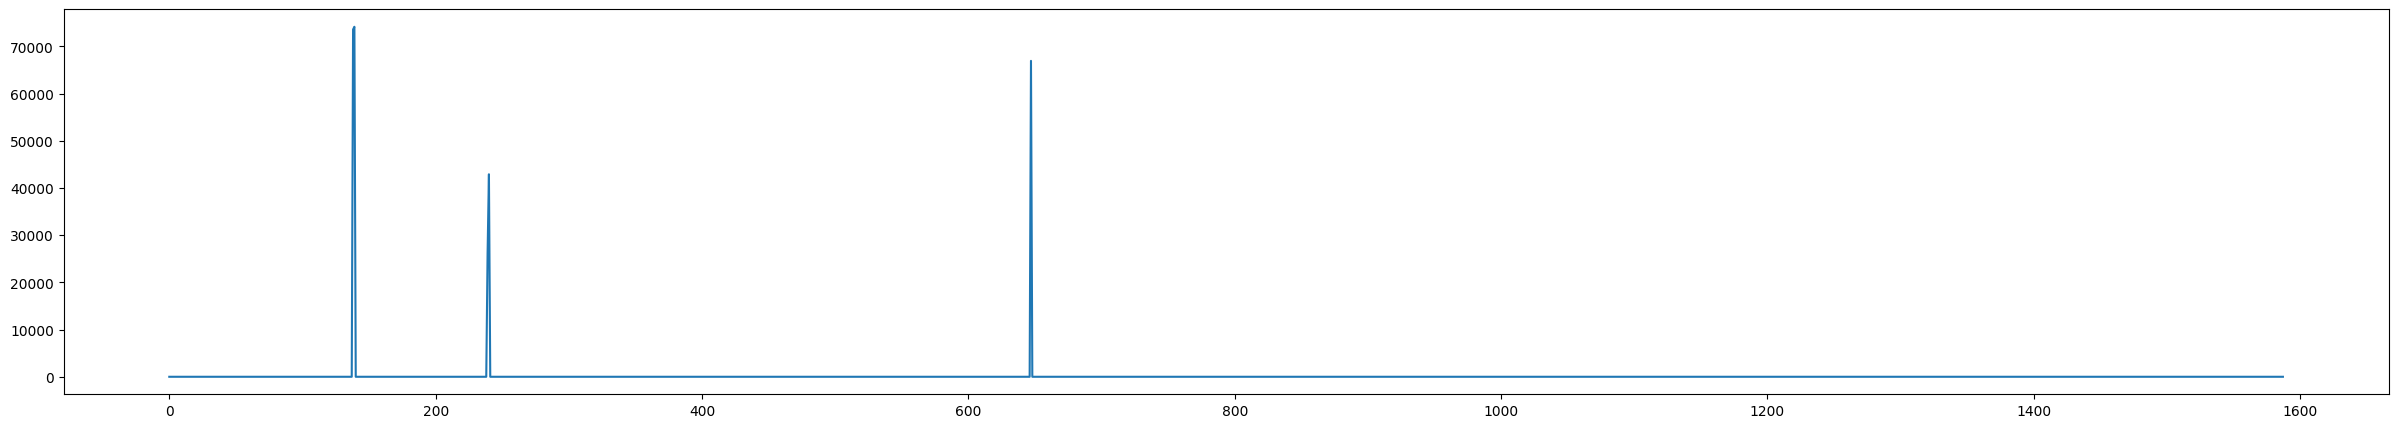

In [638]:
plt.plot(data_to_smooth)

In [697]:
chromato_cube.shape[2]

340

In [709]:
i=180-35
optimal_lambda_list=[]
for j in range(0,chromato_cube.shape[1],100):
    data_to_smooth = chromato_cube[i,j,:]
    smoother = WhittakerSmoother(lmbda=10, order=1, data_length=len(data_to_smooth))
    results = smoother.smooth_optimal(data_to_smooth, break_serial_correlation=False)
    optimally_smoothed_series = results.get_optimal().get_smoothed()
    optimal_lambda = results.get_optimal().get_lambda()
    optimal_lambda_list.append(optimal_lambda)

In [711]:
np.mean(optimal_lambda_list)

0.08953222075210474

31.622776601683793


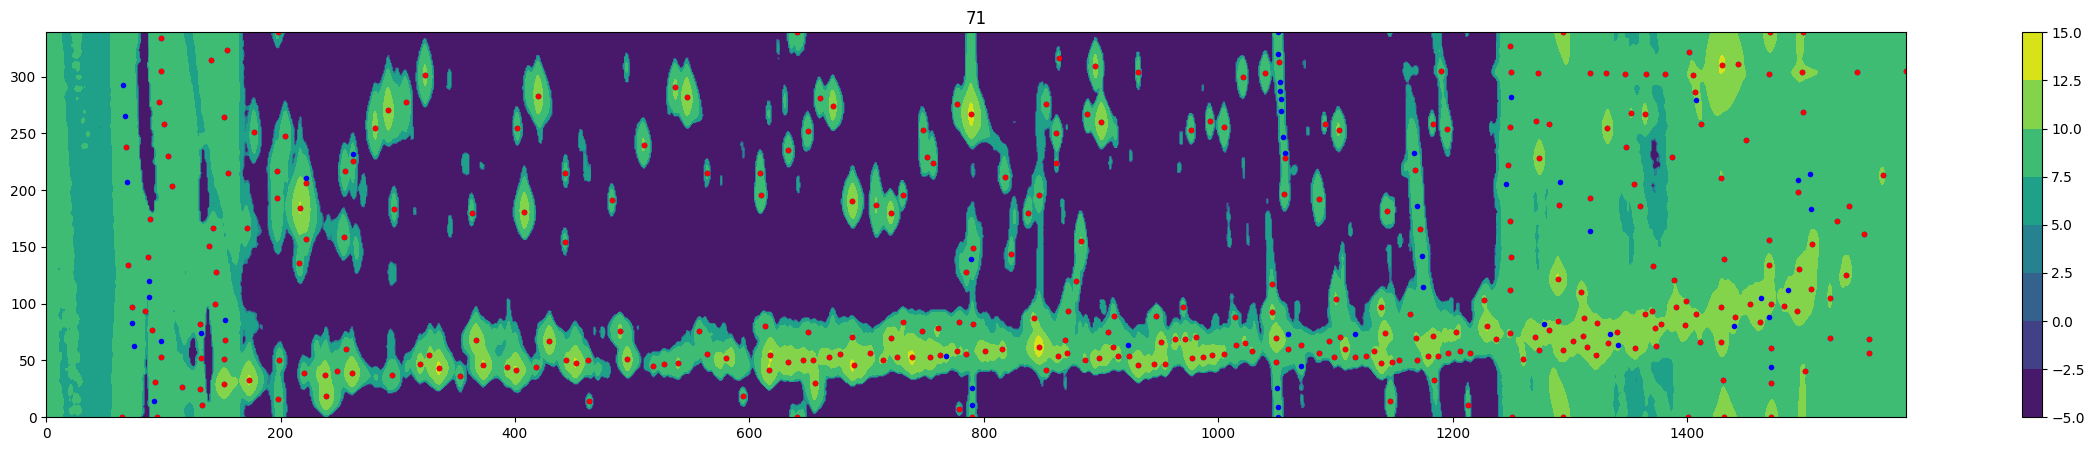

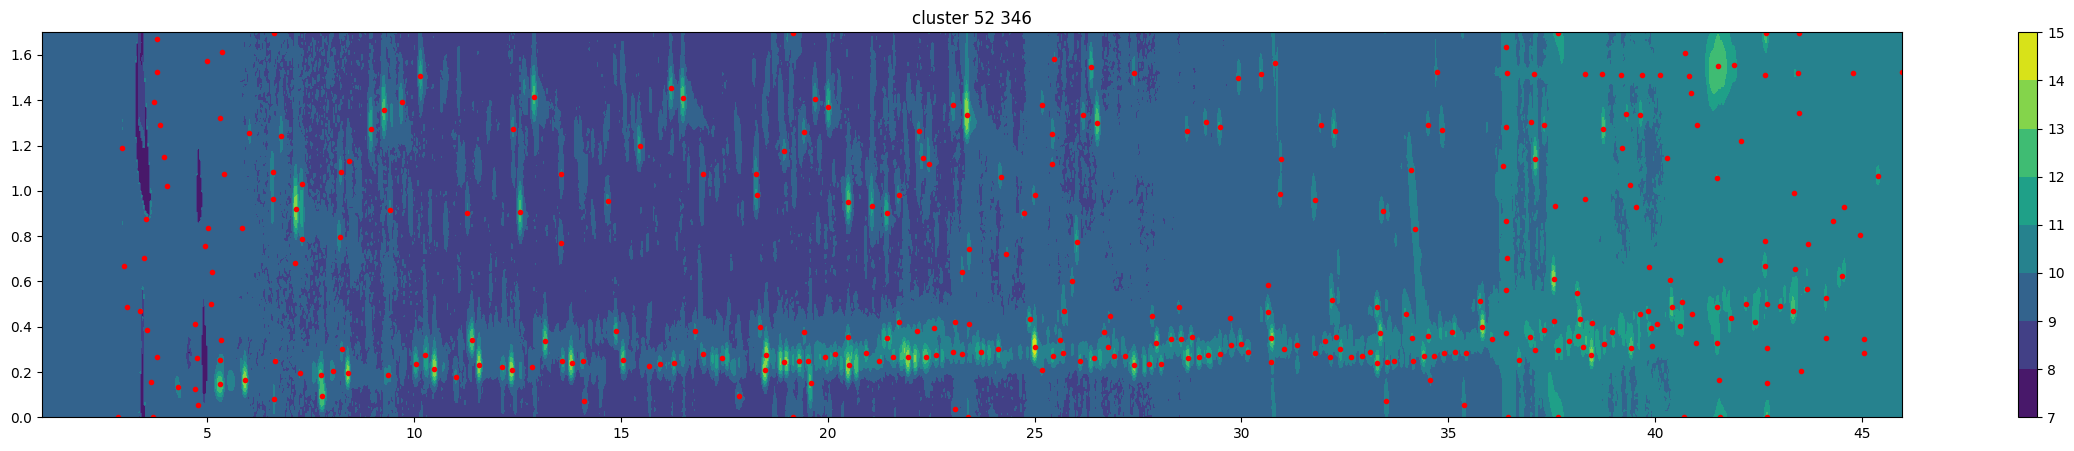

In [783]:
i=71-35
optimal_lambda_list=[]
# find optimal lambda for smoothing 
for j in range(0,chromato_cube.shape[2],10):
    data_to_smooth = chromato_cube[i,:,j]
    smoother = WhittakerSmoother(lmbda=10, order=1, data_length=len(data_to_smooth))
    results = smoother.smooth_optimal(data_to_smooth, break_serial_correlation=True)
    optimally_smoothed_series = results.get_optimal().get_smoothed()
    optimal_lambda = results.get_optimal().get_lambda()
    optimal_lambda_list.append(optimal_lambda)

optimal_lambda=np.median(optimal_lambda_list)
print(optimal_lambda)
if optimal_lambda >50 :
    optimal_lambda=50
elif optimal_lambda <5:
    optimal_lambda=5

# baseline and smooting    
correct=baseline_correct(chromato_cube[i,:,:],block_size=50,gamma=0.25, lmbd=5)

# peak detetcion 
coord, radius = dbscan_peak.detect_peak_dog((correct), abs_threshold=0,
                        rel_threshold=0.001,
                        noise_factor=5,
                        min_sigma=1, max_sigma=8,
                        sigma_ratio=1.1,
                        overlap=0.5)

# peak clusturing
distance_matrix=dbscan_peak.compute_distance_metric(coord,chromato_cube,1.7,time_rn,5, 0.1)
coordinates, clusters= dbscan_peak.cluster_peak(distance_matrix,correct,coord,0.02,min_sample_db_scan=1)


# plot
coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
fig, ax = plt.subplots()
contour =ax.contourf(np.log(correct.T))
plt.colorbar(contour, ax=ax)  # associer explicitement la colorbar à l'axe
plt.title(str(i+35))
ax.plot(coord[:,0], coord[:,1], "b.")
ax.plot(coordinates[:,0], coordinates[:,1], "r.")
chromato_safe = np.where(chromato_cube[i,:,:] <= 0, min(chromato_cube[i,:,:][chromato_cube[i,:,:]>0]), chromato_cube[i,:,:])
plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coord)-len(coordinates)) + " " + str(len(coordinates)) , log_chromato=True,  mod_time=1.7, rt1_window=0.1, rt2_window=0.2,points=coordinates_in_chromato)

# deconvolution 

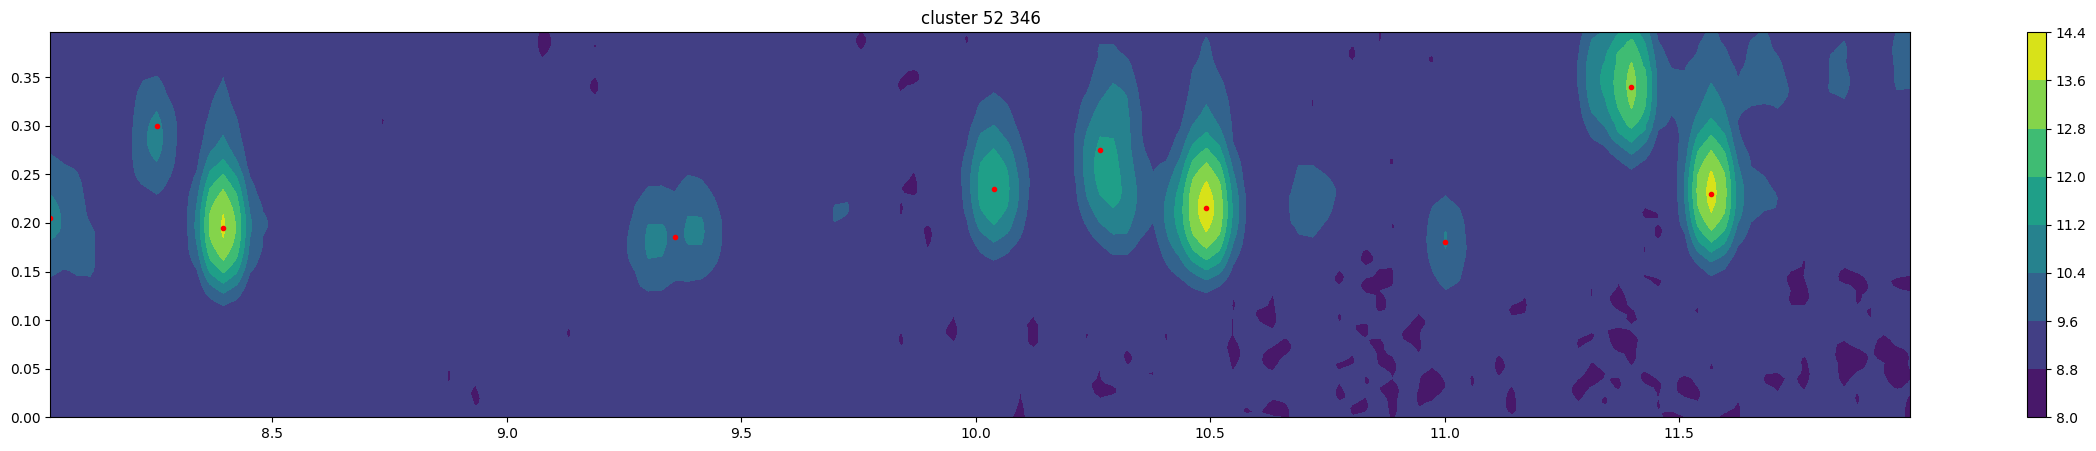

In [786]:
plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coord)-len(coordinates)) + " " + str(len(coordinates)) , log_chromato=True,  mod_time=1.7, rt1_window=2, rt2_window=0.2,points=coordinates_in_chromato, rt1=10,rt2=0.2)


In [ ]:
i=30

from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('D:/baseline_test.pdf')  # Open PDF explicitly


for i in range(chromato_cube.shape[0]):
    data_to_smooth = np.sum(chromato_cube[i,:,:],axis=1)
    smoother = WhittakerSmoother(lmbda=1, order=1, data_length=len(data_to_smooth))
    results = smoother.smooth_optimal(data_to_smooth, break_serial_correlation=True)
    optimally_smoothed_series = results.get_optimal().get_smoothed()
    optimal_lambda = results.get_optimal().get_lambda()
    print(optimal_lambda)
    if optimal_lambda >50 :
        optimal_lambda=50
    elif optimal_lambda <10:
        optimal_lambda=50
    correct=baseline_correct(chromato_cube[i,:,:],block_size=20, lmbd=optimal_lambda)
    coord, radius = dbscan_peak.detect_peak_dog(correct, abs_threshold=0,
                        rel_threshold=0.001,
                        noise_factor=5,
                        min_sigma=1, max_sigma=8,
                        sigma_ratio=1.1,
                        overlap=0.95)
    distance_matrix=dbscan_peak.compute_distance_metric(coord,chromato_cube,1.7,time_rn,5, 0.1)
    coordinates, clusters= dbscan_peak.cluster_peak(distance_matrix,correct,coord,0.05,min_sample_db_scan=1)
    coordinates_in_chromato=projection.matrix_to_chromato((coordinates), time_rn, 1.7, chromato.shape)
    fig, ax = plt.subplots()
    contour =ax.contourf(np.log(correct.T))
    plt.colorbar(contour, ax=ax)  # associer explicitement la colorbar à l'axe
    plt.title(str(i+35))
    ax.plot(coord[:,0], coord[:,1], "b.")
    ax.plot(coordinates[:,0], coordinates[:,1], "r.")
    pdf.savefig(fig)
    plt.close(fig)
    chromato_safe = np.where(chromato_cube[i,:,:] <= 0, 0.01, chromato_cube[i,:,:])
    fig=plot.visualizer2((chromato_safe,time_rn), title="cluster " + str(len(coord)-len(coordinates)) + " " , log_chromato=True,  mod_time=1.7, rt1_window=2, rt2_window=1,points=coordinates_in_chromato)
    pdf.savefig(fig)  # Save current figure to PDF
    plt.close(fig)    # Close figure to free memory
    print(str(i) + str(len(coord)-len(coordinates)))
pdf.close()  # Close the PDF file explicitly



In [787]:
radius

array([ 4.03491634,  4.88224877,  4.03491634,  6.49827312,  4.43840797,
        4.03491634,  6.49827312,  4.03491634,  4.43840797,  4.43840797,
        4.03491634, 10.46553384,  4.43840797,  4.03491634,  5.37047365,
        4.03491634,  4.03491634,  4.03491634,  5.37047365,  4.03491634,
        4.88224877,  4.88224877,  4.03491634,  4.43840797,  4.43840797,
        4.03491634,  4.43840797,  4.03491634,  4.03491634,  4.43840797,
        4.03491634,  3.66810576,  4.43840797,  4.43840797,  4.43840797,
        4.43840797,  4.03491634,  4.43840797,  5.37047365,  4.43840797,
        4.43840797,  5.37047365,  4.03491634,  4.03491634,  4.03491634,
        4.88224877,  5.37047365,  8.64920152,  3.03149237,  4.43840797,
        7.86291047,  4.43840797,  7.86291047,  6.49827312,  7.86291047,
        4.88224877,  4.03491634,  4.43840797,  4.03491634,  4.88224877,
       10.46553384,  9.51412167,  3.03149237,  7.14810043,  4.03491634,
        2.50536559,  4.03491634,  4.03491634,  6.49827312,  6.49

In [673]:
pdf.close()

In [ ]:
## group pics for déconvolution 
rt_vals= projection.matrix_to_chromato(coordinates, time_rn,1.7,chromato.shape)
rt_vals[:,0]=rt_vals[:,0]*60
scaled_rt = rt_vals / np.array([6, 0.05])
        
    # Compute Manhattan (L1) distance between all rows
penalty_matrix =0.01* cdist(scaled_rt, scaled_rt, metric='cityblock')  # sum of |ΔRT1| + |ΔRT2|
clustering = DBSCAN(eps=0.01, min_samples=1, metric='precomputed').fit(penalty_matrix)
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)
clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates):
    clusters[clustering.labels_[i]].append(i)
groups=clusters

shape = chromato.shape
mod_time=1.7
X= np.arange(time_rn[0], time_rn[1], mod_time/60)[:-1]
Y = np.linspace(0, mod_time, shape[1])
chromato = np.transpose(chromato)
fig, ax = plt.subplots()
tmp = ax.contourf(X, Y, chromato)
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i in range(5):
    points = coordinates_in_chromato[groups[i]]
    ax.plot(points[:, 0], points[:, 1], '.', color=colors[i])
plt

In [ ]:
from dbscan_peak import intensity_threshold_decision_rule

thr=[]
for m in range(chromato_cube.shape[0]) :
    sigma = estimate_sigma(chromato_cube[m,:,:], channel_axis=None)
    intensity_threshold = intensity_threshold_decision_rule(
            500, 0.001, 5, sigma, chromato_cube[m,:,:])
    thr.append(intensity_threshold)

info_par_peak=[]
for item in matches:
    indices_masses=np.where((item[1][0]['spectra'])>thr)[0]
    majority_mass=np.argmax((item[1][0]['spectra']))
    info_par_peak.append((majority_mass, indices_masses))

# Initialiser la liste des masses avec des listes vides
masses_with_peak_indices = [[[],[]] for _ in range(chromato_cube.shape[0])]

# Remplir la structure : pour chaque pic, ajouter son index aux masses correspondantes
for peak_index, peak_info in enumerate(info_par_peak):
    for mass_index in peak_info[1]:
        masses_with_peak_indices[mass_index][1].append(peak_index)
    masses_with_peak_indices[peak_info[0]][0].append(peak_index) # arg max

In [ ]:
[j for j,c in enumerate(coordinates_in_chromato) if 10.22<c[0]<10.36 and 0.15<c[1]<0.45]


In [ ]:
coords= coordinates[[255, 802]]

list_res=[]
for j in list(set(info_par_peak[255][1]) | set(info_par_peak[802][1])) :
    res=fit_all_peaks_fixed_centers(chromato_cube[j,:,:],coords,window_1=3, window_2=20,plot=True)
    list_res.append(res)

In [ ]:
spec_esti = np.zeros(len(matches[328][1][0]['spectra']))  
for j, m in enumerate(list(set(info_par_peak[255][1]) | set(info_par_peak[802][1]))) :
    spec_esti[m]= list_res[j][1]['params'][0]

print(matching_from_spectra(spec_esti))
print(matching_from_spectra(matches[802][1][0]['spectra'] ))

import plotly.graph_objects as go
import numpy as np
import kaleido

# Example spectra data
# Replace these with your actual spectra arrays
spectrum2 = spec_esti  # First spectrum for bar plot
spectrum1 = matches[802][1][0]['spectra']  # Second spectrum for line plot

# Generate x-axis values
x_values = np.arange(len(spectrum1))

# Create the bar plot for the first spectrum
bar_trace = go.Bar(x=x_values, y=spectrum1, name='Original Spectrum')

# Create the line plot for the second spectrum
line_trace = go.Scatter(x=x_values, y=spectrum2, mode='lines', name='Estimated Spectrum', line=dict(color='red'))

# Combine both plots
fig = go.Figure(data=[bar_trace, line_trace])

fig


In [ ]:
coords= np.array([([1283,   85]),
 ([1278,   84]),
 ([1279,   73]),
 ([1280,   60])])

res=fit_all_peaks_fixed_centers(tmp,coords,plot=True)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
pdf = PdfPages('D:/test_deconvo_plot2.pdf') 

mass_with_argmax = list(set([m[0]for m in info_par_peak ]))
for m in mass_with_argmax:
    peak_to_quanti = masses_with_peak_indices[m][0]
    all_peaks= masses_with_peak_indices[m][1]
    for i in peak_to_quanti:
        all_peaks.append(i)
        plt.rcParams['figure.figsize'] = [10, 5]
        fig=plot.visualizer2((chromato_cube[m,:,:],time_rn),mod_time=1.7,rt1=matches[i][0][0],rt2=matches[i][0][1],log_chromato=False,rt1_window=0.1,rt2_window=0.2, points=coordinates_in_chromato[all_peaks],
                            title=f"{m + mass_range[0]} / {i} /{ round(matches[i][0][0],4)}/ {round(matches[i][0][1],4)}", )        
        pdf.savefig(fig)  
        plt.close(fig)    

pdf.close()  

c

In [ ]:
ny, nx = tmp.shape
fitted_results = []
visited = set()
fitted_peak=[]
for i, (cy, cx) in enumerate(coords):
    if (cy, cx) in visited:
        continue

        # Cherche pics proches
    close_indices = [j for j, (yy, xx) in enumerate(coords)
                        if np.hypot(yy - cy, xx - cx) <= 50]
    for j in close_indices:
        visited.add(tuple(coords[j]))

        # Détermine zone globale pour fit
    min_x = max(0, int(min(cx - 40, *(coords[j][1] - 40 for j in close_indices))))
    max_x = min(nx, int(max(cx + 40, *(coords[j][1] + 40 for j in close_indices)))+1)
    min_y = max(0, int(min(cy -4, *(coords[j][0] - 4 for j in close_indices))))
    max_y = min(ny, int(max(cy + 4, *(coords[j][0] +4 for j in close_indices)))+1)

    sub_tmp = tmp[min_y:max_y, min_x:max_x]
    xx, yy = np.meshgrid(np.arange(min_x, max_x), np.arange(min_y, max_y))

        # Paramètres initiaux (sans centres)
    p0 = []
    fixed_centers = []
    for j in close_indices:
        yy0, xx0 = coords[j]
        amp = tmp[yy0, xx0]
        p0.extend([amp, 3, 3, 0, 0])  # no xo, yo here
        fixed_centers.append((yy0, xx0))

        # Fit
    popt, _ = curve_fit(
            lambda crd, *prm: multi_gaussian_fixed_centers(crd, *prm, centers=fixed_centers),
            (xx, yy),
            sub_tmp.ravel(),
            p0=p0
        )

        # Aire pour chaque gaussienne
    n_params = 5
    
    for k, (yy0, xx0) in enumerate(fixed_centers):
        amp, sx, sy, th, off = popt[k*n_params:(k+1)*n_params]
        fitted_peak .append(twoD_Gaussian_asym_fixed_center((xx, yy), amp, sx, sy, th, 0, xx0, yy0).reshape(sub_tmp.shape))
        area = np.sum(fitted_peak)
        fitted_results.append({
                "center": (yy0, xx0),
                "params": (amp, sx, sy, th, off),
                "area": area
            })
